In [ ]:
import numpy as np
import pandas as pd

from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import statsmodels.formula.api as smf

import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
data = pd.read_excel('gapminder.xlsx')

## Datanın təmizlənməsi - Data Cleaning

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10545 entries, 0 to 10544
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country           10545 non-null  object 
 1   year              10545 non-null  int64  
 2   infant_mortality  9092 non-null   float64
 3   life_expectancy   10545 non-null  float64
 4   fertility         10358 non-null  float64
 5   population        10360 non-null  float64
 6   gdp               7573 non-null   float64
 7   continent         10545 non-null  object 
 8   region            10545 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 741.6+ KB


In [17]:
data['year'] = data['year'].astype('category')

In [18]:
na_df = data.isna().sum().reset_index().rename(columns={'index': 'col_name', 0: 'na_count'})
na_df = na_df.sort_values('na_count', ascending=False).reset_index(drop=True)
na_df

,col_name,na_count
0,gdp,2972
1,infant_mortality,1453
2,fertility,187
3,population,185
4,country,0
5,year,0
6,life_expectancy,0
7,continent,0
8,region,0


In [19]:
na_df['pcnt'] = (na_df['na_count'] / len(data)) * 100
na_df

,col_name,na_count,pcnt
0,gdp,2972,28.183973
1,infant_mortality,1453,13.779042
2,fertility,187,1.773352
3,population,185,1.754386
4,country,0,0.000000
5,year,0,0.000000
6,life_expectancy,0,0.000000
7,continent,0,0.000000
8,region,0,0.000000


In [20]:
variables = na_df.loc[na_df['pcnt'] < 60, 'col_name'].tolist()
data = data[variables].drop(columns = 'country')

In [21]:
target = 'life_expectancy'

In [22]:
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
df_num = data[num_cols]
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10545 entries, 0 to 10544
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gdp               7573 non-null   float64
 1   infant_mortality  9092 non-null   float64
 2   fertility         10358 non-null  float64
 3   population        10360 non-null  float64
 4   life_expectancy   10545 non-null  float64
dtypes: float64(5)
memory usage: 412.0 KB


In [23]:
chr_cols = data.select_dtypes(include=['category','object']).columns.tolist()
df_chr = data[chr_cols]
df_chr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10545 entries, 0 to 10544
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   year       10545 non-null  category
 1   continent  10545 non-null  object  
 2   region     10545 non-null  object  
dtypes: category(1), object(2)
memory usage: 177.7+ KB


### Numeric dəyişənlərin təmizlənməsi

In [24]:
df_num.isna().sum()

gdp                 2972
infant_mortality    1453
fertility            187
population           185
life_expectancy        0
dtype: int64

In [25]:
med_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=200, random_state=123, n_jobs=-1),
    random_state=123,
    max_iter=10,
    initial_strategy='median',
    skip_complete=True
)

df_num = pd.DataFrame(
    med_imputer.fit_transform(df_num),
    columns = df_num.columns
)

df_num.isna().sum()

C:\Users\tarlan.cabiyev\AppData\Local\anaconda3\envs\ayna\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


gdp                 0
infant_mortality    0
fertility           0
population          0
life_expectancy     0
dtype: int64

### Character dəyişənlərin təmizlənməsi

In [26]:
df_chr.isna().sum()

year         0
continent    0
region       0
dtype: int64

In [28]:
mode_imputer = SimpleImputer(strategy = 'most_frequent')

df_chr = pd.DataFrame(
    mode_imputer.fit_transform(df_chr),
    columns = df_chr.columns
)

df_chr.isna().sum()

year         0
continent    0
region       0
dtype: int64

## Kəmiyyət dəyişənlərdə Outlier'ların həll olunması

In [27]:
num_vars = df_num.columns.drop(target)
num_vars

Index(['gdp', 'infant_mortality', 'fertility', 'population'], dtype='object')

In [28]:
for var in num_vars:
    q1 = df_num[var].quantile(0.25)
    q3 = df_num[var].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df_num[var][(df_num[var] < lower_bound) | (df_num[var] > upper_bound)]
    if not outliers.empty:
        print(f'Outliers in {var}: {outliers.values}')
        print('')

Outliers in gdp: [1.67894861e+11 3.49778187e+11 2.93540646e+11 ... 1.74488036e+11
 1.66403702e+11 1.57965898e+11]

Outliers in infant_mortality: [208.     186.9    190.     200.     208.4    209.6    204.5715 194.8
 191.61   212.     218.2    199.258  237.4    219.6    196.358  192.
 223.6    196.194  225.     251.744  203.     202.7    210.5    191.5
 212.1    216.4    196.4895 231.5    216.7    196.335  237.2    220.5
 196.296  187.5    269.2    256.8545 186.986  197.7    195.9    209.1
 188.3    211.4    214.6    209.246  225.2    213.3    186.2515 226.
 217.5    191.627  263.7    238.064  193.2835 192.8    189.4    207.6
 210.4    212.9    217.1    216.5    209.4    218.7    214.2    276.9
 247.344  196.5685 188.     206.1    208.8    214.3    211.1    212.8
 205.2    195.4    207.9    211.     270.7    232.1575 196.65   204.5
 206.8    213.3    205.3    209.2    185.6    200.7    191.     197.6
 207.6    263.6    219.992  195.7785 202.6    204.6    212.3    199.2
 206.1    195.9  

In [29]:
for var in num_vars:
    q1 = df_num[var].quantile(0.25)
    q3 = df_num[var].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df_num.loc[df_num[var] < lower_bound, var] = lower_bound
    df_num.loc[df_num[var] > upper_bound, var] = upper_bound

In [30]:
for var in num_vars:
    q1 = df_num[var].quantile(0.25)
    q3 = df_num[var].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df_num[var][(df_num[var] < lower_bound) | (df_num[var] > upper_bound)]
    if not outliers.empty:
        print(f'Outliers in {var}: {outliers.values}')
        print('')

## Keyfiyyət dəyişənlər üçün 'One Hote Encoding'

In [31]:
df_chr.head()

,year,continent,region
0,1960,Europe,Southern Europe
1,1960,Africa,Northern Africa
2,1960,Africa,Middle Africa
3,1960,Americas,Caribbean
4,1960,Americas,South America


In [32]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

df_chr = pd.DataFrame(
    ohe.fit_transform(df_chr),
    columns = ohe.get_feature_names_out(df_chr.columns),
    index = df_chr.index
)

df_chr.head()

,year_1960,year_1961,year_1962,year_1963,year_1964,year_1965,year_1966,year_1967,year_1968,year_1969,...,region_Northern Europe,region_Polynesia,region_South America,region_South-Eastern Asia,region_Southern Africa,region_Southern Asia,region_Southern Europe,region_Western Africa,region_Western Asia,region_Western Europe
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [46]:
df = pd.concat([df_num, df_chr], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10545 entries, 0 to 10544
Data columns (total 89 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   gdp                               10545 non-null  float64
 1   infant_mortality                  10545 non-null  float64
 2   fertility                         10545 non-null  float64
 3   population                        10545 non-null  float64
 4   life_expectancy                   10545 non-null  float64
 5   year_1960                         10545 non-null  float64
 6   year_1961                         10545 non-null  float64
 7   year_1962                         10545 non-null  float64
 8   year_1963                         10545 non-null  float64
 9   year_1964                         10545 non-null  float64
 10  year_1965                         10545 non-null  float64
 11  year_1966                         10545 non-null  float64
 12  year

## 'Multicollinearity' probleminin həll olunması və VIF (Variance Inflation Factor)

In [47]:
X_data = df.drop(columns = [target])

In [48]:
def compute_vif_table(X_data):
    vifs = {}
    
    for feature in X_data.columns:
        y = X_data[feature]
        X = X_data.drop(columns=[feature])
    
        model = LinearRegression().fit(X, y)
        r_squared = model.score(X, y)
    
        if r_squared == 1.0:
            vif = np.inf
        else:
            vif = 1 / (1 - r_squared)
            
        vifs[feature] = vif

    vif_values = pd.DataFrame(list(vifs.items()), columns=['Feature', 'VIF'])
    vif_values = vif_values[~np.isinf(vif_values['VIF'])].sort_values('VIF', ascending=False).reset_index()
    return(vif_values)

In [49]:
vif_values = compute_vif_table(X_data)
vif_values

,index,Feature,VIF
0,84,region_Southern Europe,1.887002e+06
1,65,continent_Oceania,2.659302e+05
2,63,continent_Asia,1.273823e+04
3,62,continent_Americas,2.847397e+03
4,86,region_Western Asia,5.068322e+02
...,...,...,...
83,29,year_1985,1.000983e+00
84,33,year_1989,1.000912e+00
85,30,year_1986,1.000856e+00
86,32,year_1988,1.000852e+00


In [50]:
features = vif_values.Feature
len(features)

88

In [51]:
while vif_values.loc[0, 'VIF'] >= 3 and len(features) > 1:
    print(vif_values.loc[0,['Feature','VIF']]) 
    
    features = vif_values.loc[1:, 'Feature'].tolist()
    print('Number of features:',len(features))
    
    X_data = X_data[features]
    vif_values = compute_vif_table(X_data)

Feature    region_Southern Europe
VIF                1887002.287373
Name: 0, dtype: object
Number of features: 87
Feature    continent_Oceania
VIF            261298.336757
Name: 0, dtype: object
Number of features: 86
Feature    continent_Asia
VIF           5298.121522
Name: 0, dtype: object
Number of features: 85
Feature    continent_Americas
VIF                774.207488
Name: 0, dtype: object
Number of features: 84
Feature    continent_Africa
VIF               75.423537
Name: 0, dtype: object
Number of features: 83
Feature    fertility
VIF         4.891817
Name: 0, dtype: object
Number of features: 82
Feature    continent_Europe
VIF                4.104366
Name: 0, dtype: object
Number of features: 81
Feature         gdp
VIF        3.208102
Name: 0, dtype: object
Number of features: 80
Feature    infant_mortality
VIF                3.263884
Name: 0, dtype: object
Number of features: 22


In [52]:
vif_values

,index,Feature,VIF
0,2,region_Western Asia,2.260606
1,0,region_Western Africa,2.133220
2,1,region_Eastern Africa,2.132315
3,4,region_Caribbean,1.963373
4,5,region_South America,1.881897
5,7,region_South-Eastern Asia,1.761908
6,8,region_Eastern Europe,1.760461
7,9,region_Northern Europe,1.736945
8,6,region_Southern Asia,1.647441
9,10,region_Central America,1.595358


In [53]:
df = df[[target] + features]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10545 entries, 0 to 10544
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   life_expectancy                   10545 non-null  float64
 1   region_Western Africa             10545 non-null  float64
 2   region_Eastern Africa             10545 non-null  float64
 3   region_Western Asia               10545 non-null  float64
 4   region_Middle Africa              10545 non-null  float64
 5   region_Caribbean                  10545 non-null  float64
 6   region_South America              10545 non-null  float64
 7   region_Southern Asia              10545 non-null  float64
 8   region_South-Eastern Asia         10545 non-null  float64
 9   region_Eastern Europe             10545 non-null  float64
 10  region_Northern Europe            10545 non-null  float64
 11  region_Central America            10545 non-null  float64
 12  regi

## Standartlaşdırma / Normallaşdırma

In [65]:
print(df['region_Northern Africa'].unique())
print(df['region_Southern Asia'].unique())
print(df['region_Central America'].unique())

print(df['population'].min())
print(df['population'].max())

[-0.18308346  5.46198987]
[-0.2125976   4.70372193]
[-0.2125976   4.70372193]
-0.8649980754349552
2.030293383394417


In [55]:
scaler = StandardScaler()

df.iloc[:, 1:] = scaler.fit_transform(df.iloc[:, 1:])

df.head()

,life_expectancy,region_Western Africa,region_Eastern Africa,region_Western Asia,region_Middle Africa,region_Caribbean,region_South America,region_Southern Asia,region_South-Eastern Asia,region_Eastern Europe,...,region_Western Europe,region_Southern Africa,region_Eastern Asia,region_Central Asia,region_Melanesia,population,region_Northern America,region_Polynesia,region_Micronesia,region_Australia and New Zealand
0,62.87,-0.307692,-0.307692,-0.328305,-0.212598,-0.274921,-0.263371,-0.212598,-0.239046,-0.239046,...,-0.198307,-0.166667,-0.183083,-0.166667,-0.166667,-0.736639,-0.128388,-0.128388,-0.104542,-0.104542
1,47.50,-0.307692,-0.307692,-0.328305,-0.212598,-0.274921,-0.263371,-0.212598,-0.239046,-0.239046,...,-0.198307,-0.166667,-0.183083,-0.166667,-0.166667,0.022316,-0.128388,-0.128388,-0.104542,-0.104542
2,35.98,-0.307692,-0.307692,-0.328305,4.703722,-0.274921,-0.263371,-0.212598,-0.239046,-0.239046,...,-0.198307,-0.166667,-0.183083,-0.166667,-0.166667,-0.445914,-0.128388,-0.128388,-0.104542,-0.104542
3,62.97,-0.307692,-0.307692,-0.328305,-0.212598,3.637412,-0.263371,-0.212598,-0.239046,-0.239046,...,-0.198307,-0.166667,-0.183083,-0.166667,-0.166667,-0.863123,-0.128388,-0.128388,-0.104542,-0.104542
4,65.39,-0.307692,-0.307692,-0.328305,-0.212598,-0.274921,3.796929,-0.212598,-0.239046,-0.239046,...,-0.198307,-0.166667,-0.183083,-0.166667,-0.166667,0.781699,-0.128388,-0.128388,-0.104542,-0.104542


In [64]:
print(df['region_Northern Africa'].unique())
print(df['region_Southern Asia'].unique())
print(df['region_Central America'].unique())

print(df['population'].min())
print(df['population'].max())

[-0.18308346  5.46198987]
[-0.2125976   4.70372193]
[-0.2125976   4.70372193]
-0.8649980754349552
2.030293383394417


## Datanın bölünməsi - Splitting the data

In [66]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [67]:
(len(X_train) + len(X_test)) == len(df) == (len(y_train) + len(y_test))

True

## GLM (Generalized Linear Model) alqoritmasının qurulması
## Proqnozlaşdırıcıların əhəmiyyət səviyyələri - Significance levels of predictors

In [68]:
train = pd.concat([y_train, X_train], axis=1)
test = pd.concat([y_test, X_test], axis=1)

In [72]:
train.columns = train.columns.str.replace(' ', '_').str.replace('-', '_')
features = train.columns.drop(target)
test.columns = train.columns

In [84]:
f'{target} ~ {" + ".join(features)}'

'life_expectancy ~ region_Western_Africa + region_Eastern_Africa + region_Western_Asia + region_Middle_Africa + region_Caribbean + region_South_America + region_Southern_Asia + region_South_Eastern_Asia + region_Eastern_Europe + region_Northern_Europe + region_Central_America + region_Northern_Africa + region_Western_Europe + region_Southern_Africa + region_Eastern_Asia + region_Central_Asia + region_Melanesia + population + region_Northern_America + region_Polynesia + region_Micronesia + region_Australia_and_New_Zealand'

In [85]:
def fit_glm_return_pvals(train, y, x):
    formula = f'{y} ~ {" + ".join(x)}'

    model = smf.glm(formula=formula, data=train, family=sm.families.Gaussian()).fit()

    coef_tab = pd.DataFrame({
        'names': model.params.index.tolist(),
        'estimate': model.params.values,
        'std_error': model.bse.values,
        'z_value': model.tvalues,  
        'p_value': model.pvalues.values
    })

    p_values = (
        coef_tab.loc[coef_tab['names'] != 'Intercept', ['names', 'p_value']]
        .sort_values('p_value', ascending=False)
        .reset_index(drop=True)
    )

    return model, coef_tab, p_values

model, coef_tab, p_values = fit_glm_return_pvals(train, target, features)

In [87]:
coef_tab

,names,estimate,std_error,z_value,p_value
Intercept,Intercept,64.834790,0.079717,813.312028,0.000000e+00
region_Western_Africa,region_Western_Africa,-5.971549,0.116656,-51.189574,0.000000e+00
region_Eastern_Africa,region_Eastern_Africa,-5.411233,0.115648,-46.790726,0.000000e+00
region_Western_Asia,region_Western_Asia,-1.482746,0.119464,-12.411667,2.258996e-35
region_Middle_Africa,region_Middle_Africa,-4.499206,0.099932,-45.022799,0.000000e+00
region_Caribbean,region_Caribbean,-0.998100,0.111536,-8.948698,3.596992e-19
region_South_America,region_South_America,-1.391081,0.109057,-12.755559,2.902852e-37
region_Southern_Asia,region_Southern_Asia,-2.868938,0.101872,-28.162110,1.703268e-174
region_South_Eastern_Asia,region_South_Eastern_Asia,-2.299875,0.105166,-21.868944,5.133124e-106
region_Eastern_Europe,region_Eastern_Europe,-0.786674,0.106010,-7.420749,1.164601e-13


In [88]:
p_values

,names,p_value
0,region_Northern_America,3.521917e-02
1,region_Australia_and_New_Zealand,4.204521e-03
2,region_Northern_Europe,2.456581e-03
3,region_Western_Europe,1.239429e-04
4,region_Eastern_Asia,1.586280e-10
5,region_Eastern_Europe,1.164601e-13
6,region_Polynesia,4.423324e-18
7,region_Caribbean,3.596992e-19
8,population,1.327645e-19
9,region_Central_America,9.159458e-28


## Addım-addım geriyə doğru aradan qaldırılma - Stepwise Backward Elimination

In [91]:
while (p_values.loc[0, 'p_value'] >= 0.05):
    worst_name = p_values.loc[0, 'names']
    print(p_values.loc[0])  
    
    features = features.drop(worst_name) # drop worst and refit
    model, coef_tab, p_values = fit_glm_return_pvals(train, target, features)

In [97]:
final_pvals = coef_tab[['names', 'p_value']].sort_values('p_value', ascending=False)
final_pvals#.shape

,names,p_value
region_Northern_America,region_Northern_America,3.521917e-02
region_Australia_and_New_Zealand,region_Australia_and_New_Zealand,4.204521e-03
region_Northern_Europe,region_Northern_Europe,2.456581e-03
region_Western_Europe,region_Western_Europe,1.239429e-04
region_Eastern_Asia,region_Eastern_Asia,1.586280e-10
region_Eastern_Europe,region_Eastern_Europe,1.164601e-13
region_Polynesia,region_Polynesia,4.423324e-18
region_Caribbean,region_Caribbean,3.596992e-19
population,population,1.327645e-19
region_Central_America,region_Central_America,9.159458e-28


## Proqnozlar

In [98]:
X_test = sm.add_constant(test[features], has_constant='add')
X_test.head()

,const,region_Western_Africa,region_Eastern_Africa,region_Western_Asia,region_Middle_Africa,region_Caribbean,region_South_America,region_Southern_Asia,region_South_Eastern_Asia,region_Eastern_Europe,...,region_Western_Europe,region_Southern_Africa,region_Eastern_Asia,region_Central_Asia,region_Melanesia,population,region_Northern_America,region_Polynesia,region_Micronesia,region_Australia_and_New_Zealand
741,1.0,-0.307692,-0.307692,-0.328305,-0.212598,-0.274921,-0.263371,-0.212598,-0.239046,-0.239046,...,-0.198307,-0.166667,-0.183083,-0.166667,-0.166667,0.115984,-0.128388,-0.128388,-0.104542,-0.104542
5345,1.0,3.250000,-0.307692,-0.328305,-0.212598,-0.274921,-0.263371,-0.212598,-0.239046,-0.239046,...,-0.198307,-0.166667,-0.183083,-0.166667,-0.166667,-0.581195,-0.128388,-0.128388,-0.104542,-0.104542
6983,1.0,-0.307692,-0.307692,-0.328305,-0.212598,-0.274921,-0.263371,-0.212598,-0.239046,4.183300,...,-0.198307,-0.166667,-0.183083,-0.166667,-0.166667,2.030293,-0.128388,-0.128388,-0.104542,-0.104542
10210,1.0,-0.307692,-0.307692,-0.328305,-0.212598,-0.274921,3.796929,-0.212598,-0.239046,-0.239046,...,-0.198307,-0.166667,-0.183083,-0.166667,-0.166667,2.030293,-0.128388,-0.128388,-0.104542,-0.104542
10214,1.0,-0.307692,-0.307692,-0.328305,-0.212598,-0.274921,-0.263371,-0.212598,-0.239046,-0.239046,...,-0.198307,-0.166667,-0.183083,-0.166667,-0.166667,-0.482946,-0.128388,-0.128388,-0.104542,-0.104542


In [101]:
actual = test[target].astype(float)

In [102]:
pred = model.predict(X_test)

## Reqressiya Modelinin Perormansının Qiymətləndirilməsi

In [113]:
ss_res = np.sum((actual - pred) ** 2)
ss_tot = np.sum((actual - np.mean(actual)) ** 2)
r2 = 1 - ss_res / ss_tot
r2

np.float64(0.5188247560020405)

In [114]:
n = len(actual)
p = len(features) 

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adj_r2

np.float64(0.5137500410605471)

In [105]:
mae_val = round(mean_absolute_error(actual, pred), 1)
mae_val

5.6

In [110]:
mse_val = round(mean_squared_error(actual, pred), 1)
mse_val

54.7

In [112]:
rmse_val = round(np.square(mse_val), 1)
rmse_val

np.float64(2992.1)

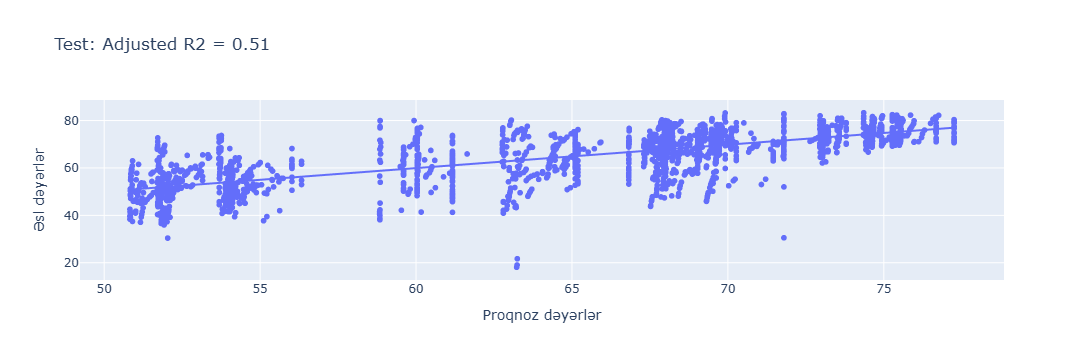

In [115]:
# Plot

results = pd.DataFrame(np.column_stack([pred, actual]), columns=['pred', 'actual'])

fig = px.scatter(
    results, x='pred', y='actual',
    trendline='ols',
    labels={'pred': 'Proqnoz dəyərlər', 'actual': 'Əsl dəyərlər'},
    title=f'Test: Adjusted R2 = {adj_r2:.2f}'
)
fig.show()

## 'Overfitting' / 'Underfitting'

In [116]:
X_train = sm.add_constant(train[features], has_constant='add')
y_actual = train[target].astype(float)
y_pred = model.predict(X_train)

In [117]:
n = len(y_actual)
p = len(features) 
ss_res = np.sum((y_actual - y_pred) ** 2)
ss_tot = np.sum((y_actual - np.mean(y_actual)) ** 2)
r2 = 1 - ss_res / ss_tot
y_adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
y_adj_r2

np.float64(0.52960040685636)

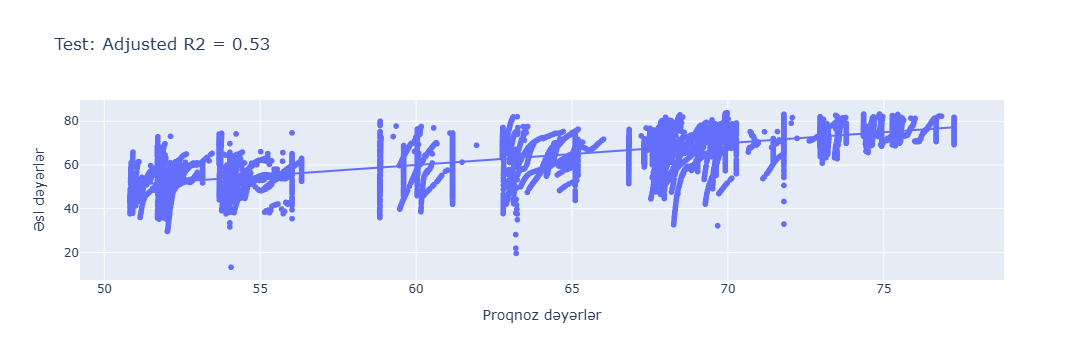

In [118]:
# Plot

y_results = pd.DataFrame(np.column_stack([y_pred, y_actual]), columns=['pred', 'actual'])

y_fig = px.scatter(
    y_results, x='pred', y='actual',
    trendline='ols',
    labels={'pred': 'Proqnoz dəyərlər', 'actual': 'Əsl dəyərlər'},
    title=f'Test: Adjusted R2 = {y_adj_r2:.2f}'
)
y_fig.show()

In [119]:
model = LinearRegression().fit(X_train, y_train)
r_2_test = model.score(X_test, y_test)
r_2_train = model.score(X_train, y_train)
print('Train:',round(r_2_train,2),'\n',
      'Test:',round(r_2_test,2))

Train: 0.53 
 Test: 0.52
